# This notebook was used to analyze the distributions of image width, height, and aspect ratio to guide data filtering.

In [1]:
import pandas as pd
import glob
import os
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import numpy as np
from sklearn.linear_model import RANSACRegressor
import scipy
from scipy.stats import norm
from sklearn.mixture import GaussianMixture
from PIL import Image

In [11]:
ssd_path = "/Volumes/PortableSSD/PDS_eugenie" # Path to the SSD to adapt
df = pd.read_csv(os.path.join(ssd_path, "table_database.csv"))

# Histogram visualization

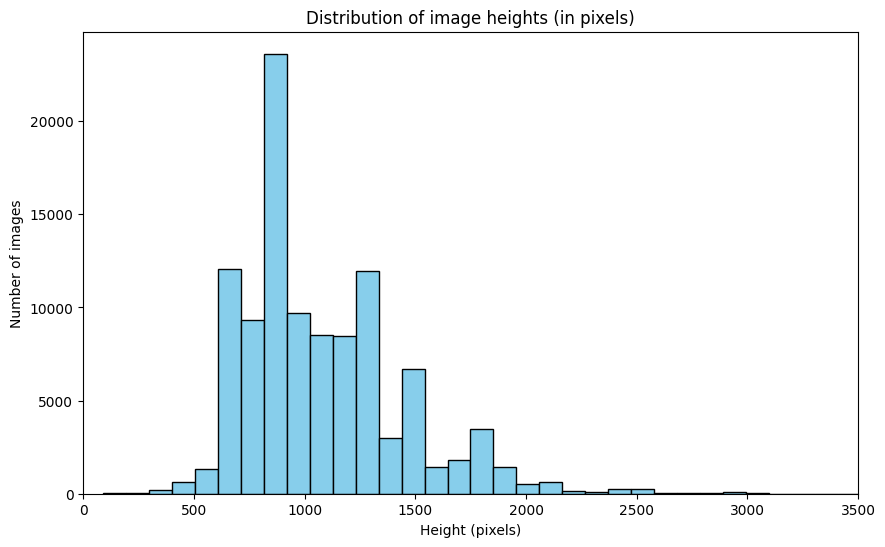

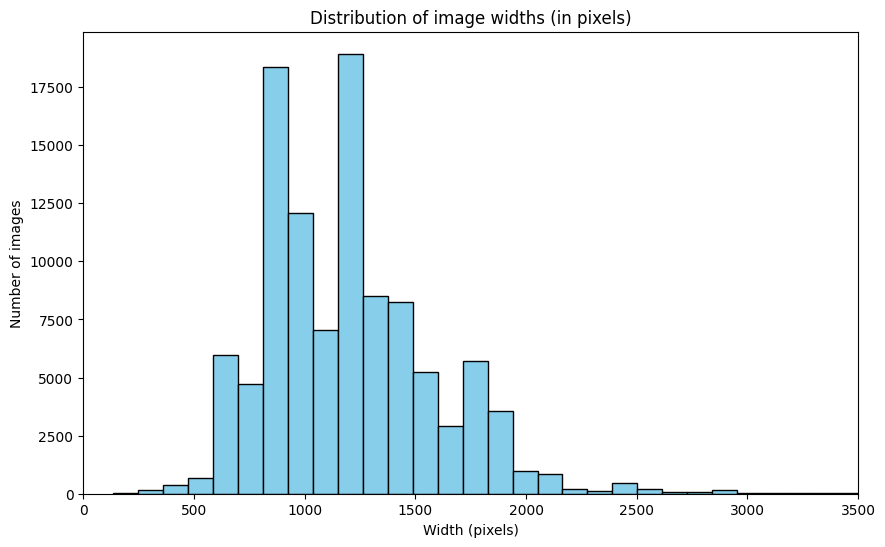

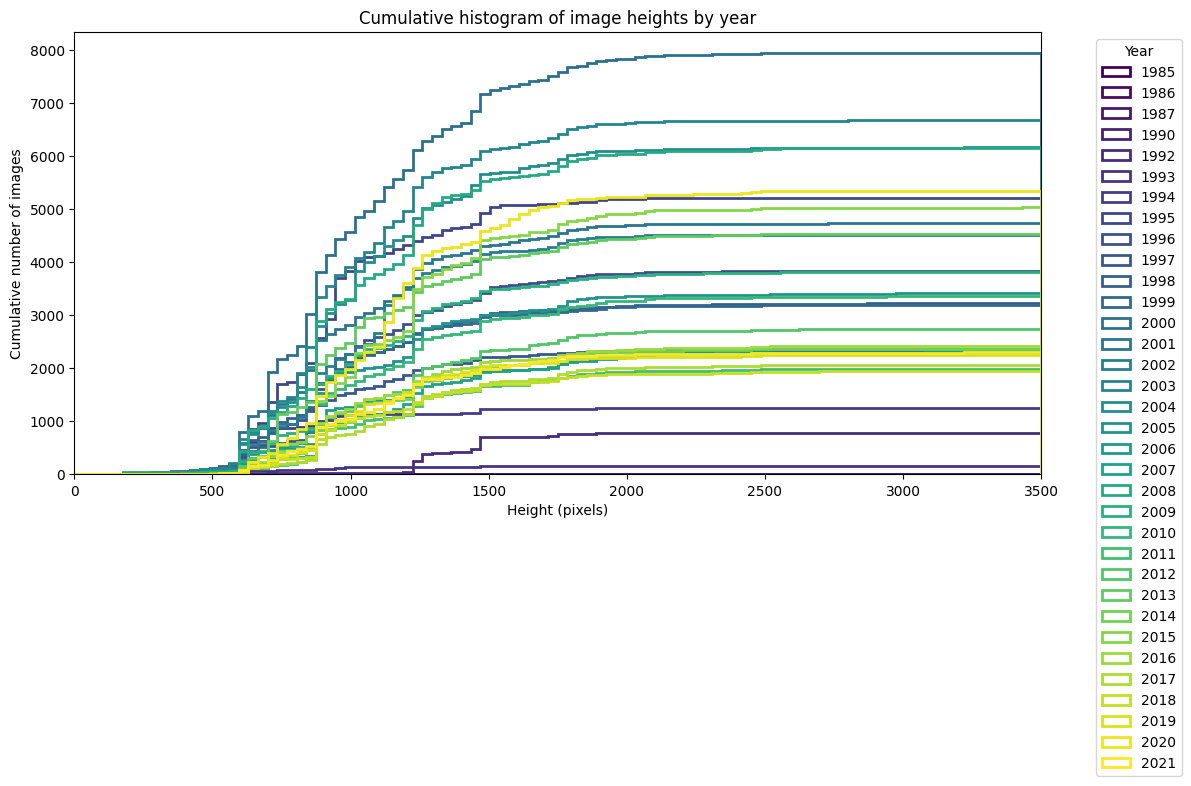

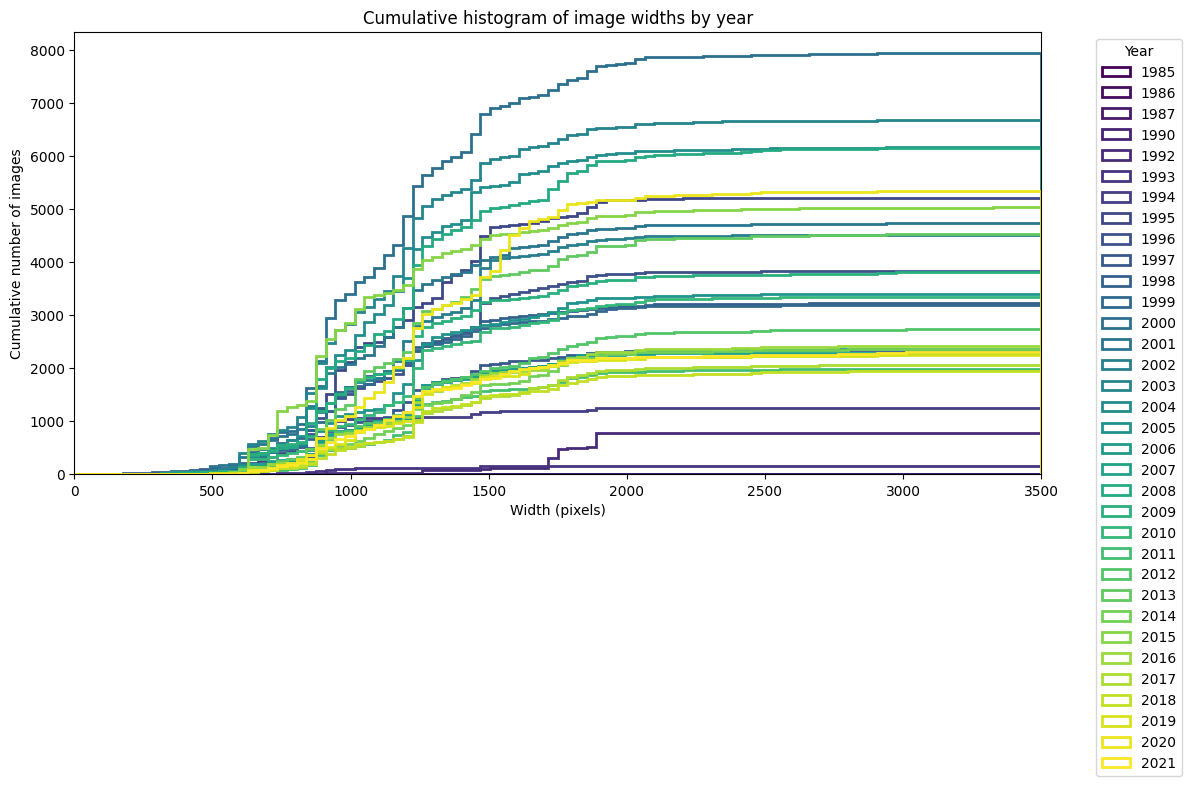

Average height: 1071.17 pixels
Average width: 1200.17 pixels
Average height/width ratio: 1.17


In [5]:
# Height histogram
plt.figure(figsize=(10, 6))
plt.hist(df["hauteur"], bins=100, color='skyblue', edgecolor='black')
plt.title("Distribution of image heights (in pixels)")
plt.xlabel("Height (pixels)")
plt.ylabel("Number of images")
plt.xlim(0, 3500)
plt.show()

# Width histogram
plt.figure(figsize=(10, 6))
plt.hist(df["largeur"], bins=100, color='skyblue', edgecolor='black')
plt.title("Distribution of image widths (in pixels)")
plt.xlabel("Width (pixels)")
plt.ylabel("Number of images")
plt.xlim(0, 3500)
plt.show()

# Cumulative histogram of image heights by year with color gradient
years = sorted(df["annee"].dropna().unique())
years = [int(y) for y in years if not np.isnan(y)]
colors = cm.viridis(np.linspace(0, 1, len(years)))

plt.figure(figsize=(12, 7))
for i, year in enumerate(years):
    heights = df[df["annee"] == year]["hauteur"].dropna()
    plt.hist(
        heights, bins=100, range=(0, 3500), histtype='step',
        cumulative=True, color=colors[i], linewidth=2,
        label=str(year)
    )

plt.title("Cumulative histogram of image heights by year")
plt.xlabel("Height (pixels)")
plt.ylabel("Cumulative number of images")
plt.xlim(0, 3500)
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

# Cumulative histogram of image widths by year with color gradient
plt.figure(figsize=(12, 7))
for i, year in enumerate(years):
    widths = df[df["annee"] == year]["largeur"].dropna()
    plt.hist(
        widths, bins=100, range=(0, 3500), histtype='step',
        cumulative=True, color=colors[i], linewidth=2,
        label=str(year)
    )

plt.title("Cumulative histogram of image widths by year")
plt.xlabel("Width (pixels)")
plt.ylabel("Cumulative number of images")
plt.xlim(0, 3500)
plt.legend(title="Year", bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()


print(f"Average height: {df['hauteur'].mean():.2f} pixels")
print(f"Average width: {df['largeur'].mean():.2f} pixels")
if "ratio" not in df.columns:
        df["ratio"] = df["largeur"] / df["hauteur"]
print(f"Average height/width ratio: {df['ratio'].mean():.2f}")

# Scatter plot visualization

/var/folders/hs/0_x2lvwn2j15899cprv0r6cr0000gn/T/ipykernel_64053/2755691493.py:57: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  colors = cm.get_cmap("tab20", len(years))


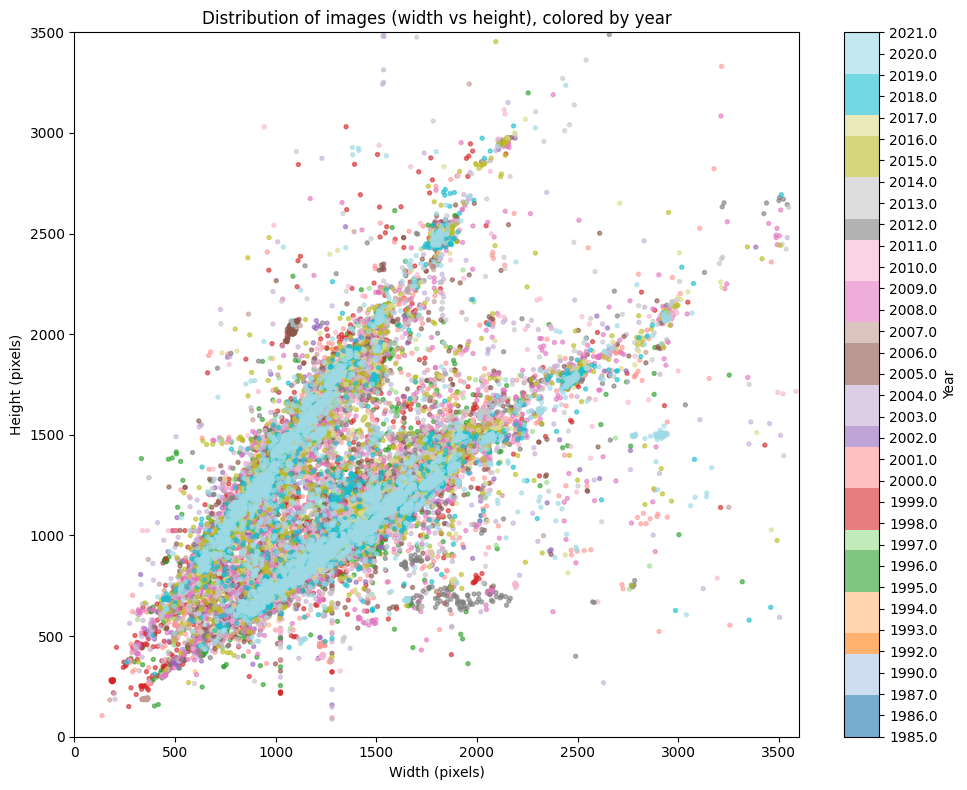

[{'fit': 1, 'slope': np.float64(0.6863831867146775), 'intercept': np.float64(57.54794269661261)}, {'fit': 2, 'slope': np.float64(1.3081973783306733), 'intercept': np.float64(52.222497604637965)}]


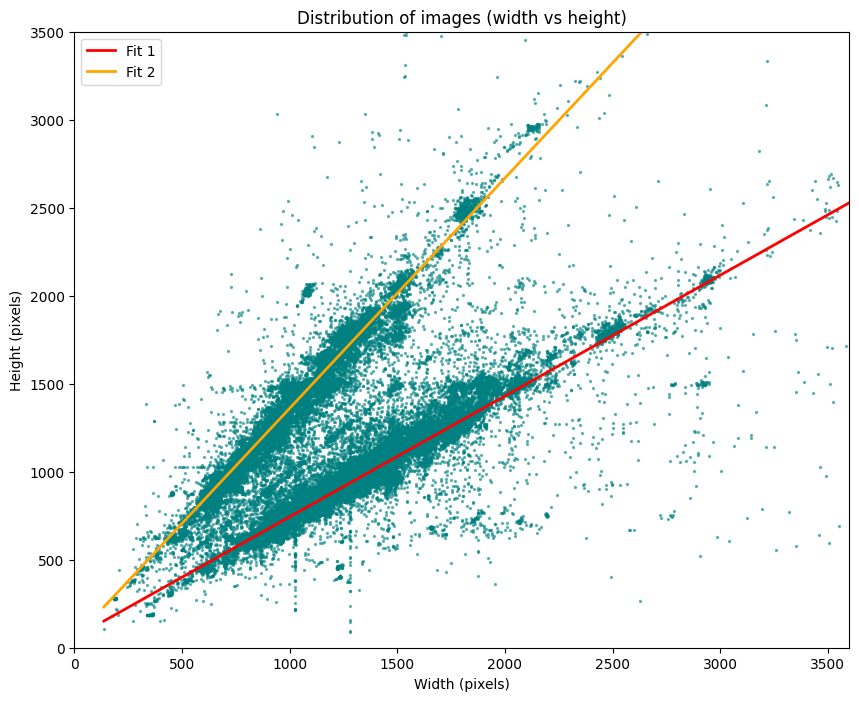

In [12]:
def scatter_all_images(df):
    plt.figure(figsize=(10, 8))
    scatter_all_images = plt.scatter(df["largeur"], df["hauteur"], alpha=0.5, color='teal', s=2)
    plt.title("Distribution of images (width vs height)")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Height (pixels)")
    plt.xlim(0, 3600)
    plt.ylim(0, 3500)
    return scatter_all_images

def fit_scatter_plot(scatter_plot):
    offsets = scatter_plot.get_offsets()
    x = offsets[:, 0]
    y = offsets[:, 1]

    sort_idx = np.argsort(x)
    x_sorted = x[sort_idx]

    # Fit the first regression line 
    ransac1 = RANSACRegressor()
    ransac1.fit(x.reshape(-1, 1), y)
    line1 = ransac1.predict(x_sorted.reshape(-1, 1))

    # Get inlier/outlier mask
    mask1 = ransac1.inlier_mask_
    x2 = x[~mask1]
    y2 = y[~mask1]

    ax = scatter_plot.axes

    ax.plot(x_sorted, line1, color='red', linewidth=2, label='Fit 1')

    regression_info = []
    slope1 = ransac1.estimator_.coef_[0]
    intercept1 = ransac1.estimator_.intercept_
    regression_info.append({'fit': 1, 'slope': slope1, 'intercept': intercept1})

    # If outliers exist, fit a second regression line
    if len(x2) > 0:
        ransac2 = RANSACRegressor()
        ransac2.fit(x2.reshape(-1, 1), y2)
        line2 = ransac2.predict(x_sorted.reshape(-1, 1))
        ax.plot(x_sorted, line2, color='orange', linewidth=2, label='Fit 2')
        slope2 = ransac2.estimator_.coef_[0]
        intercept2 = ransac2.estimator_.intercept_
        regression_info.append({'fit': 2, 'slope': slope2, 'intercept': intercept2})

    ax.legend()
    plt.draw()  

    return regression_info

# Scatter plot width vs height, colored by year
def scatter_all_images_by_year(df):
    df_plot = df.dropna(subset=["annee", "largeur", "hauteur"]).copy()
    years = sorted(df_plot["annee"].unique())
    colors = cm.get_cmap("tab20", len(years))
    
    plt.figure(figsize=(10, 8))
    sc = plt.scatter(
        df_plot["largeur"], df_plot["hauteur"],
        c=df_plot["annee"].map({y: i for i, y in enumerate(years)}),
        cmap=colors, alpha=0.6, s=8
    )
    cbar = plt.colorbar(sc, ticks=range(len(years)))
    cbar.ax.set_yticklabels([str(y) for y in years])
    cbar.set_label("Year")
    plt.title("Distribution of images (width vs height), colored by year")
    plt.xlabel("Width (pixels)")
    plt.ylabel("Height (pixels)")
    plt.xlim(0, 3600)
    plt.ylim(0, 3500)
    plt.tight_layout()
    plt.show()

scatter_all_images_by_year(df)

scatter_plot = scatter_all_images(df)
regression_info = fit_scatter_plot(scatter_plot)
print(regression_info)
plt.show()